# **WEEK 1**


> *Rotations, the Doubling Map, and the Seeds of Chaos*



## **ROTATIONS ON A CIRCLE**
*'Stimulating orbits for rational and irrational parameters to investigate equidistribution'*




### **INTRODUCTION**:

The circle rotation map is
$$
x \mapsto x+\alpha \pmod 1
$$

Starting from an initial point $x_0$, the same value $\alpha$ is repeatedly
added. Whenever the result exceeds $1$, the value wraps back around the
interval by taking modulo $1$.

The objective is to compare the behaviour for rational and irrational values of
$\alpha$.


---


### **Key observations and notes:**


The irrational orbit explores all points on the circle unlike the rational one which only ends up at four distinct points
The graphical representation shows us where we end up after each step whereas the histogram depicts how often each part is visited
Furthermore, as the number of iterations (depicted by variable 'N') increases for the irrational orbit, the histogram starts to flatten relatively compared to a simulation with 200 iterations. this is because the 'visits' to points on a circle become more frequent and eventually spread out after many iterations

      


---
### **Simulating orbits to investigate equidistribution**
This is to visualise how rational and irrational orbits behave, and can be easily explained by running the code with different values for α.



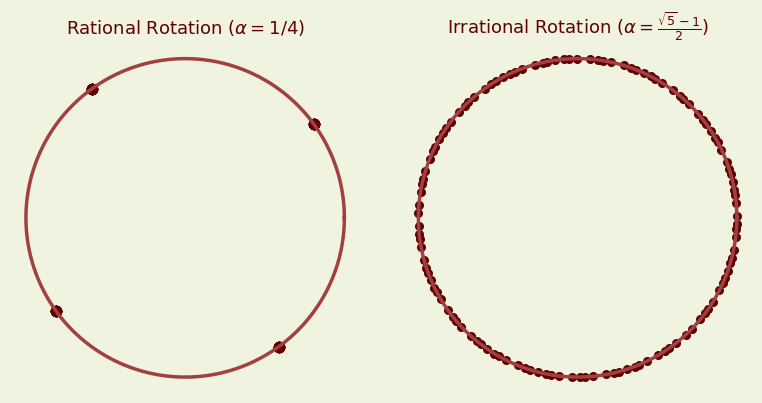

In [ ]:
# ==========================================================
# Circle Map on the Unit Circle
# x_{n+1} = (x_n + α) mod 1
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Circle Map
# ----------------------------

def circle_map(alpha, x0, n):
    orbit = [x0]
    x = x0

    for _ in range(n):
        x = (x + alpha) % 1
        orbit.append(x)

    return np.array(orbit)

# ----------------------------
# Parameters
# ----------------------------

alpha1 = 1/4                    # Rational
alpha2 = (np.sqrt(5)-1)/2       # Irrational

x0 = 0.1
N = 120

orbit1 = circle_map(alpha1,x0,N)
orbit2 = circle_map(alpha2,x0,N)

# ----------------------------
# Plot
# ----------------------------

fig,ax = plt.subplots(1,2,figsize=(8,4))
fig.patch.set_facecolor('#F1F3E1') # Set figure background color

theta = np.linspace(0,2*np.pi,400)

# Draw circles
for a in ax:
    a.plot(np.cos(theta),np.sin(theta),color='#A04040',lw=2.5)
    a.set_aspect('equal')
    a.axis('off')

# Rational orbit
ax[0].scatter(
    np.cos(2*np.pi*orbit1),
    np.sin(2*np.pi*orbit1),
    s=50,
    color='#600000'
)

ax[0].set_title(r"Rational Rotation ($\alpha=1/4$)",fontsize=13, color='#600000')

# Irrational orbit
ax[1].scatter(
    np.cos(2*np.pi*orbit2),
    np.sin(2*np.pi*orbit2),
    s=30,
    color='#600000'
)

ax[1].set_title(r"Irrational Rotation ($\alpha=\frac{\sqrt{5}-1}{2}$)",fontsize=13, color='#600000')

plt.tight_layout()
plt.savefig('circle_map.png', dpi=300)
plt.show()

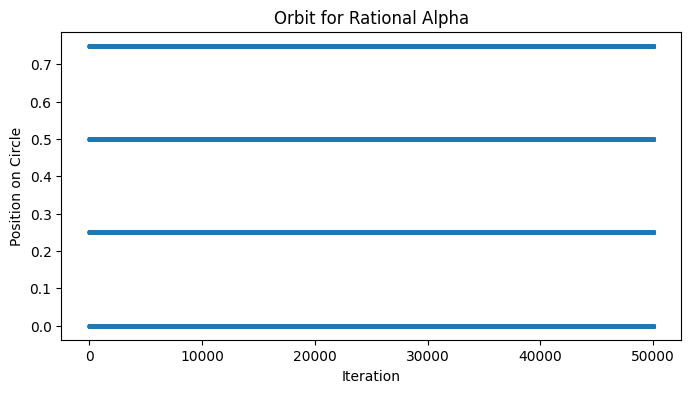

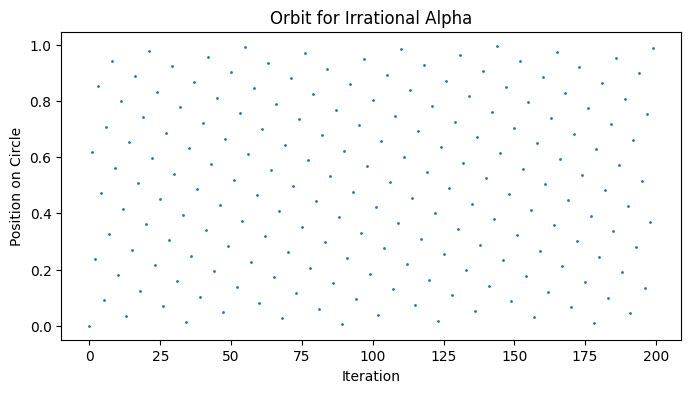

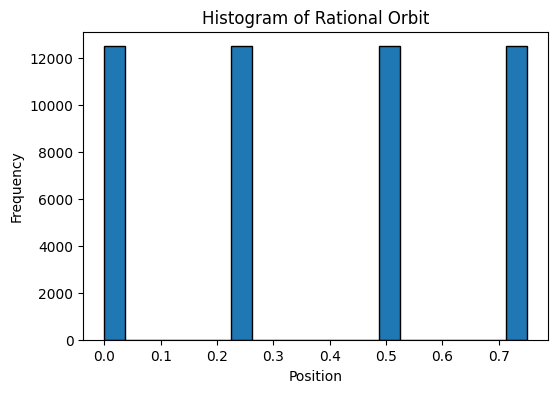

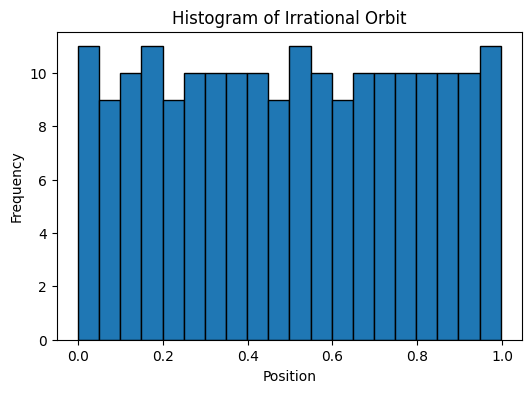

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
def orbit(alpha, x0, N):
    """
    Simulates the circle rotation map.

    Parameters:
        alpha : rotation amount
        x0    : starting point
        N     : number of iterations

    Returns:
        x : array containing the orbit
    """

    x = np.zeros(N)
    x[0] = x0

    for i in range(1, N):
        x[i] = (x[i-1] + alpha) % 1

    return x
alpha = 1/4
x0 = 0
N = 50000

orbit_rational = orbit(alpha, x0, N)
alpha = (np.sqrt(5)-1)/2
x0 = 0
N = 200

orbit_irrational = orbit(alpha, x0, N)
plt.figure(figsize=(8,4))

plt.plot(orbit_rational, '.', markersize=5)

plt.title("Orbit for Rational Alpha")
plt.xlabel("Iteration")
plt.ylabel("Position on Circle")

plt.savefig("orbit_rational.png", dpi=300, bbox_inches="tight")

plt.show()
plt.figure(figsize=(8,4))

plt.plot(orbit_irrational, '.', markersize=2)

plt.title("Orbit for Irrational Alpha")
plt.xlabel("Iteration")
plt.ylabel("Position on Circle")

plt.savefig("orbit_irrational.png", dpi=300, bbox_inches="tight")

plt.show()
plt.figure(figsize=(6,4))

plt.hist(orbit_rational, bins=20, edgecolor='black')

plt.title("Histogram of Rational Orbit")
plt.xlabel("Position")
plt.ylabel("Frequency")
plt.savefig("histogram_rational.png", dpi=300, bbox_inches="tight")
plt.show()
plt.figure(figsize=(6,4))

plt.hist(orbit_irrational, bins=20, edgecolor='black')

plt.title("Histogram of Irrational Orbit")
plt.xlabel("Position")
plt.ylabel("Frequency")

# Save the figure
plt.savefig("histogram_irrational.png", dpi=300, bbox_inches="tight")

# Display the figure
plt.show()

## **THE DOUBLING MAP**
*'The divergence of two nearby trajectories'*

### **KEY NOTES:**
Now we look at the doubling map which asks the question, if two objects start with a minor difference will they end up at similar places?
In this way, the doubling map demonstrates sensitive dependence on initial conditions. Two trajectories that start extremely close together diverge rapidly under repeated application of the map. This occurs because multiplication by two shifts the binary expansion one place to the left each iteration. A small difference in a later binary digit eventually becomes the leading digit, causing the trajectories to separate significantly. The logarithmic plot of the separation shows approximately exponential growth during the initial iterations.


---





### **Why the doubling map is 'chaotic'**:
The doubling map is considered chaotic because it exhibits *sensitive dependency* on initial conditions. Two trajectories that begin close together separate rapidly under repeated application of the map. Although the rule is completely deterministic, tiny initial differences are amplified, making long-term prediction practically impossible without knowing the exact starting point.


---





### **Simulating two nearby trajectories:**
Now we will be plotting the separation of two nearby trajectories on a logarithmic and normal scale to visualise how far they end up from eachother even if they start from relatively close initial positions

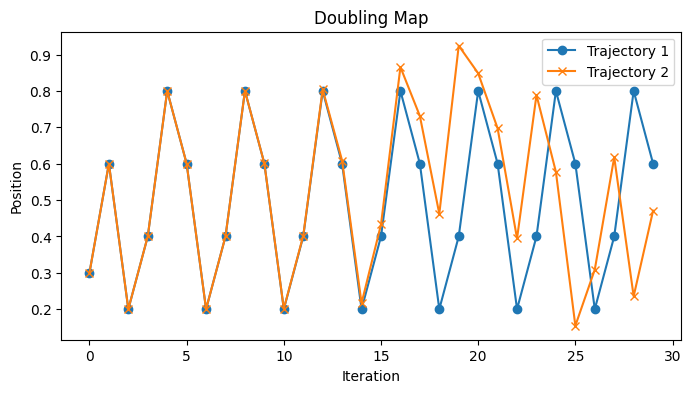

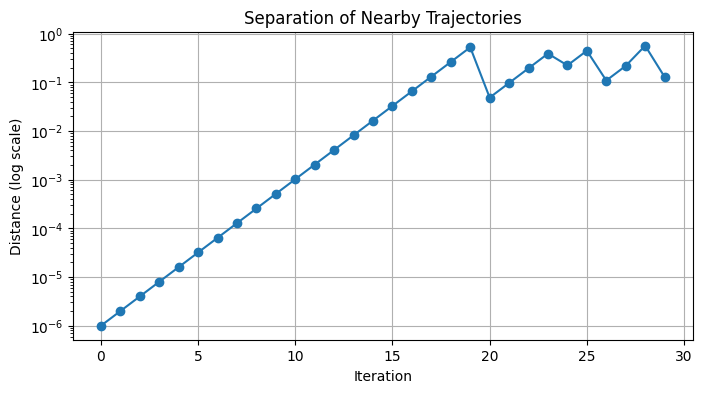

In [ ]:
# import numpy as np
import matplotlib.pyplot as plt
def doubling_map(x0, N):
    x = np.zeros(N)
    x[0] = x0

    for i in range(1, N):
        x[i] = (2*x[i-1]) % 1

    return x
x1 = 0.300000
x2 = 0.300001

N = 30
orbit1 = doubling_map(x1, N)
orbit2 = doubling_map(x2, N)
plt.figure(figsize=(8,4))

plt.plot(orbit1, 'o-', label='Trajectory 1')
plt.plot(orbit2, 'x-', label='Trajectory 2')

plt.xlabel("Iteration")
plt.ylabel("Position")
plt.title("Doubling Map")

plt.legend()
plt.savefig("doubling_map.png", dpi=300, bbox_inches="tight")

plt.show()
distance = np.abs(orbit1 - orbit2)
plt.figure(figsize=(8,4))

plt.semilogy(distance, 'o-')

plt.xlabel("Iteration")
plt.ylabel("Distance (log scale)")
plt.title("Separation of Nearby Trajectories")

plt.grid(True)

plt.savefig("separation.png", dpi=300, bbox_inches="tight")

plt.show()


## **SYMBOLIC DYNAMICS**
*Chaos as a loss of information*


### **Sensitive dependency and loss of information:**
To demonstrate how the doubling map is exactly bit shifting in binary, we'll be using numbers expressed in base (2) system ie. binary representation.

For example:

$$
0.110101\ldots \longrightarrow 1.10101\ldots \xrightarrow{\text{mod }1} 0.10101\ldots
$$
Thus, each iteration simply shifts the binary sequence left by one digit.

 The disappearance of the first digit illustrates the key observation to take away, that the doubling map deletes the first digit of a binary number.

 This gives us a simple explanation of sensitive dependency on intial conditions. Two numbers that differ by a single binary digit to the far right are iterated using the doubling map and at first, the difference in trajectories is intially none, until that differing digit becomes the leading digit and hence causes a major difference in trajectories.

 Due to this, the doubling map also illustrates chaos as a loss of information,
 where after each iteration, the leftmost binary number is discarded and will not and cannot be recovered from its current state. As a result, each step causes a loss of inormation in the form of one binary digit about the starting point of the value. Although the map is operated by a fixed rule, long-term prediction requires knowledge of more and more binary digits of the starting point, and such loss of information leads to increased and drastic unreliability in predictions, which is one of the main hallmarks of chaos itself.
